In [1]:
from src import sph_cpp
from src.visualization import *
import matplotlib.pyplot as plt

### Define simulation parameters

In [2]:
res = 0.1
no_steps = 1000
Lx = 5.0
Ly = 5.0
rho0 = 1.0
kappa = 1.2
v0 = 2
dt = 0.005
c_s = 10
beta = 0.07
kinematic_viscosity = 0.000001


inflow_factor = 0.1
outflow_factor = 0.1

central_radius = 0.5
boundary_width = 0.02
max_force = 0

### Run simulation

In [3]:
params = sph_cpp.SimulationParams(
    res, no_steps, Lx, Ly, rho0, kappa, v0, dt, c_s, beta, central_radius, boundary_width, max_force, inflow_factor, outflow_factor, kinematic_viscosity
)

# Initialize ParticleList
particle_list = sph_cpp.ParticleList(params)

# Setup initial conditions
particle_list.init_grid()
particle_list.init_mass()
particle_list.init_vel()
particle_list.init_type()

# Run simulation
rerun_sim = True
if rerun_sim:
    particle_list.integrate()


Nx = int(Lx/res)
Ny = int(Ly/res)
init_particles = Nx*Ny
masses = params.rho0*params.Lx*params.Ly/params.init_particles

In [22]:
time = np.linspace(0,no_steps*dt, no_steps+1)

### Read data

In [5]:
positions, velocities, types, drag_forces = read_all_output("all_output.bin")

### Create animation

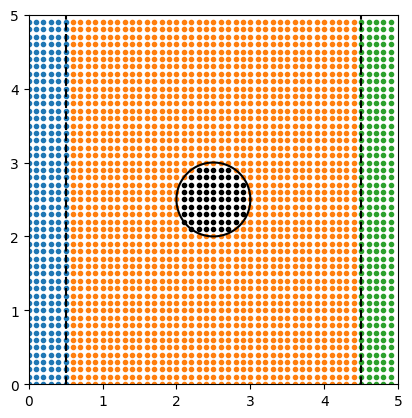

In [6]:
anim = animate_types(positions, velocities, types, params, masses, interval=100)

In [7]:
anim.save("figures/temp.mp4")

CalledProcessError: Command '['ffmpeg', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', '640x480', '-pix_fmt', 'rgba', '-framerate', '10.0', '-loglevel', 'error', '-i', 'pipe:', '-vcodec', 'h264', '-pix_fmt', 'yuv420p', '-y', 'figures/temp.mp4']' returned non-zero exit status 255.

### Number of particles over time

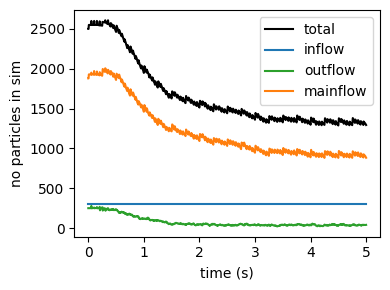

In [24]:
no_particles_in_sim = np.array([len(pos) for pos in positions])
no_inflow_particles = np.zeros(len(positions))
no_mainflow_particles = np.zeros(len(positions))
no_outflow_particles = np.zeros(len(positions))
for i in range(len(positions)):
    inflow_mask = types[i]==0.0
    mainflow_mask = types[i]==2.0
    outflow_mask = types[i]==1.0
    no_inflow_particles[i] = len(positions[i][inflow_mask])
    no_mainflow_particles[i] = len(positions[i][mainflow_mask])
    no_outflow_particles[i] = len(positions[i][outflow_mask])

fig, ax = plt.subplots(figsize=(4,3))

ax.plot(time, no_particles_in_sim, color="black", label="total")
ax.plot(time, no_inflow_particles, color="C0", label="inflow")
ax.plot(time, no_outflow_particles, color="C2", label="outflow")
ax.plot(time, no_mainflow_particles, color="C1", label="mainflow")
ax.set_xlabel("time (s)")
ax.set_ylabel("no particles in sim")
ax.legend()
fig.tight_layout()
fig.savefig("figures/particles_in_sim3.png", dpi=300)
plt.show()


### Drag force

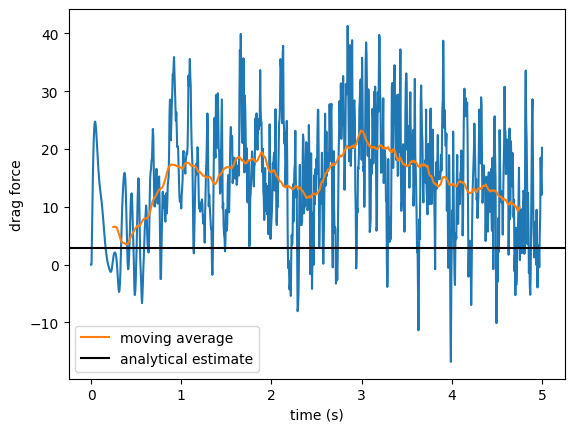

In [28]:
window_size = 100
moving_avg = np.convolve(drag_forces, np.ones(window_size)/window_size, mode='valid')
avg_time = np.convolve(time, np.ones(window_size)/window_size, mode='valid')

fig, ax = plt.subplots()
ax.plot(time, drag_forces)
ax.plot(avg_time, moving_avg, label="moving average")
ax.set_xlabel("time (s)")
ax.set_ylabel("drag force")

analytical_drag = 1/2*rho0*v0**2*1.4*2*central_radius
ax.axhline(analytical_drag, color="black", label="analytical estimate")
ax.legend()
plt.show()

### Particle positions & times

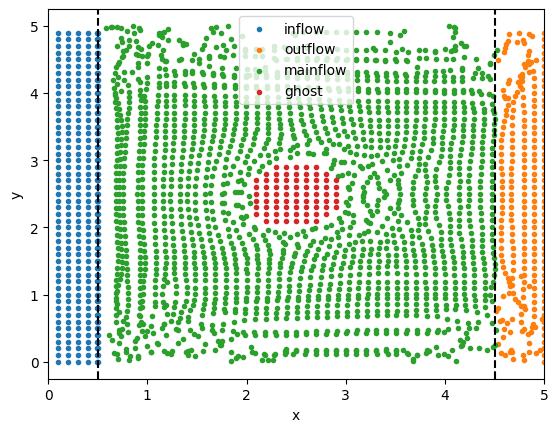

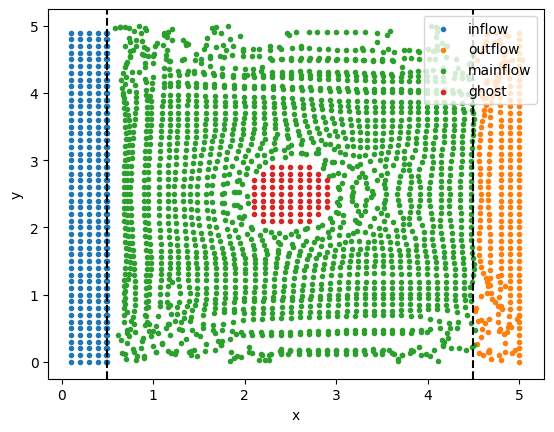

In [ ]:
idx = 50



fig, ax = plt.subplots()
ax.scatter(positions[idx][:,0][types[idx]==0.0], positions[idx][:,1][types[idx]==0.0], marker='.', label="inflow")
ax.scatter(positions[idx][:,0][types[idx]==1.0], positions[idx][:,1][types[idx]==1.0], marker='.', label="outflow")
ax.scatter(positions[idx][:,0][types[idx]==2.0], positions[idx][:,1][types[idx]==2.0], marker='.', label="mainflow")
ax.scatter(positions[idx][:,0][types[idx]==3.0], positions[idx][:,1][types[idx]==3.0], marker='.', label="ghost")
ax.legend()
ax.set_xlim(0,5)
ax.axvline(inflow_factor*Lx, color="black", linestyle="--")
ax.axvline((1-outflow_factor)*Lx, color="black", linestyle="--")
ax.set_xlabel("x")
ax.set_ylabel("y")
#fig.savefig("figures/positions.png",dpi=300)
plt.show()

fig, ax = plt.subplots()
ax.scatter(positions[idx][:,0][types[idx]==0.0], positions[idx][:,1][types[idx]==0.0], marker='.', label="inflow")
ax.scatter(positions[idx][:,0][types[idx]==1.0], positions[idx][:,1][types[idx]==1.0], marker='.', label="outflow")
ax.scatter(positions[idx][:,0][types[idx]==2.0], positions[idx][:,1][types[idx]==2.0], marker='.', label="mainflow")
ax.scatter(positions[idx][:,0][types[idx]==3.0], positions[idx][:,1][types[idx]==3.0], marker='.', label="ghost")
ax.legend()
ax.axvline(inflow_factor*Lx, color="black", linestyle="--")
ax.axvline((1-outflow_factor)*Lx, color="black", linestyle="--")
ax.set_xlabel("x")
ax.set_ylabel("y")
#fig.savefig("figures/positions_all.png",dpi=300)
plt.show()

### Energy calculation

In [ ]:
E_total, E_bulk, E_rand, E_object = calculate_energies(positions, velocities, params, masses)

fig, ax = plt.subplots(figsize=(4,3))
ax.plot(E_total, label="total")
ax.plot(E_bulk, label="flow")
ax.plot(E_rand, label="thermal")
ax.plot(E_object, label="object potential")
ax.set_xlabel("time")
ax.set_ylabel("energy")
ax.legend()
fig.tight_layout()
fig.savefig("figures/energy_leapfrog.png", dpi=300)
plt.show()

TypeError: 'float' object is not subscriptable